# Comparing Sea Ice plots depending on remapping

## Origin of Files

In [1]:
#Short history of commands and origin of files:
# The commands are for the PI dataset, the other datasets have been created exactly analogous 
# just the names of the files have been exchanged, they can be found in the folders
# /data/modeldata/ICON/icon-paleo/LIG.kepler/remapped_r2b4  &  ./data/modeldata/ICON/icon-paleo/LIG.kepler.ghg/remapped_r2b4

#
#Merging:
#        cdo mergetime ../PI.kepler.mk_atm_2d_ml_*.nc PI.kepler_atm2d_merged.nc
#
#Regridding:
#        getting gridfiles/icon_grid_0012_R02B04_G.nc
#                ==> downloaded original from ICON paleo website, is the gridfile for R02B04 grid
#        creating gridfiles/target_grid_1_5.txt
#                ==> got from Kiras 0.75 grid, changed numbers pretty self explanatory!
#
#        Creating weightfile in gridfiles:
#        cdo gendis,gridfiles/target_grid_1_5.txt -setgrid,gridfiles/icon_grid_0012_R02B04_G.nc  PI.kepler_atm2d_merged.nc gridfiles/weightfile_R02B04_to_1_5_deg
#
#        Actual Remapping:
#        cdo -remap,gridfiles/target_grid_1_5.txt,gridfiles/weightfile_R02B04_to_1_5_deg PI.kepler_atm2d_merged.nc PI.kepler_atm2d_merged_remapped.nc
#
#Selecting the relevant years:
#        cdo selyear,1770/1800 PI.kepler_atm2d_merged_remapped.nc PI.kepler_atm2d_merged_remapped_1770_1800.nc
#
#
#Extracting DIFFERENT data:
#
#        Creating Means:
#        cdo ymonmean PI.kepler_atm2d_merged_remapped_1770_1800.nc ymonmean_PI.kepler_atm2d_merged_remapped_1770_1800.nc
#



## Basic Import Statements

In [2]:
# %%
import xarray as xr
import numpy as np
#from scipy.stats import pearsonr
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
#from tqdm import tqdm
import os
import socket
import psutil
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Loading rcParams

In [3]:
import importlib
import plot_settings
importlib.reload(plot_settings)
plot_settings.load_rcParams()

## Loading Data of both Remappings (ymonmeans)

In [4]:
def determine_system() -> str:
    many_cores  = os.cpu_count() > 16
    lots_of_ram = psutil.virtual_memory().total > 64 * 1024**3  # more than 64 GB
    if many_cores and lots_of_ram:
        return 'Cluster'
    else:
        return 'Jakob_Laptop'

if determine_system() == 'Jakob_Laptop':
    location_of_data = '../'
else:
    location_of_data = '/data/modeldata/ICON/icon-paleo/'

print('Loading ymonmean Data, which was remapped from Kira ')
print('Just a note: the data has a NH in it, but it is NOT just the Northern Hemisphere but the whole world')
#PI      = xr.open_dataset(location_of_data + 'PI.kepler/remapped_r2b4/ymonmean_PI.kepler_atm2d_merged_remapped_1770_1800.nc')
#LIG     = xr.open_dataset(location_of_data + 'LIG.kepler/remapped_r2b4/ymonmean_LIG.kepler_atm2d_merged_remapped_1770_1800.nc')
#LIG_ghg = xr.open_dataset(location_of_data + 'LIG.kepler.ghg/remapped_r2b4/ymonmean_LIG.kepler.ghg_atm2d_merged_remapped_1770_1800.nc')

# or stands for other remapping
PI_or      = xr.open_dataset(location_of_data + 'PI.kepler/merged/PI.kepler_NH_1770-1800_ymonmean.nc')
LIG_or     = xr.open_dataset(location_of_data + 'LIG.kepler/merged/LIG.kepler_NH_1770-1800_ymonmean.nc')
LIG_ghg_or = xr.open_dataset(location_of_data + 'LIG.kepler.ghg/merged/LIG.kepler.ghg_NH_1770-1800_ymonmean.nc')


PI  = xr.open_dataset('../PI.kepler/remapped_r2b4/ymonmean_PI.kepler_atm2d_merged_remapped_1770_1800.nc')
LIG  = xr.open_dataset('../LIG.kepler/remapped_r2b4/ymonmean_LIG.kepler_atm2d_merged_remapped_1770_1800.nc')
LIG_ghg = xr.open_dataset('../LIG.kepler.ghg/remapped_r2b4/ymonmean_LIG.kepler.ghg_atm2d_merged_remapped_1770_1800.nc')


Loading ymonmean Data, which was remapped from Kira 
Just a note: the data has a NH in it, but it is NOT just the Northern Hemisphere but the whole world


## Deriving Worldmap Anomalies difference between mappings (LIG-PI)_map1 - (LIG-PI)_map2

In [33]:
#extract Juli
def extract_month(PI: xr.DataArray, month: int = 7) -> xr.DataArray:
    PI_mon = PI.sel(time=PI.time.dt.month == month)
    return PI_mon

#def remove_useless_dims(ds):
#    if 'height_2' in PI.dims:
#        ds = ds.squeeze('height_2')
#    if 'height' in PI.dims:
#        ds = ds.squeeze('height')
#    return ds

def remove_useless_dims(ds):
    for var in ["height_2", "height"]:
        # Case 1: it's a dimension of size 1 → squeeze it out
        if var in ds.dims and ds.sizes[var] == 1:
            ds = ds.squeeze(var, drop=True)

        # Case 2: it's a coordinate but NOT a dimension → drop it
        elif var in ds.coords and var not in ds.dims:
            ds = ds.drop_vars(var)

    return ds

def get_annual_mean(ds):
    #takes annual mean only for ymonmean data!
    return ds.mean(dim='time')

PI,LIG,LIG_ghg = [remove_useless_dims(ds) for ds in [PI,LIG,LIG_ghg]]


PI_Jul      = extract_month(PI,      month =7)
LIG_Jul     = extract_month(LIG,     month =7)
LIG_ghg_Jul = extract_month(LIG_ghg, month =7)

PI_Jan      = extract_month(PI,      month =1)
LIG_Jan     = extract_month(LIG,     month =1)
LIG_ghg_Jan = extract_month(LIG_ghg, month =1)

PI_ann,LIG_ann,LIG_ghg_ann = [get_annual_mean(ds) for ds in [PI,LIG,LIG_ghg]] #ann stands for annual not Anomaly




# derive anomaly
Anom_Jul_LIG_PI = LIG_Jul - PI_Jul
Anom_Jan_LIG_PI = LIG_Jan - PI_Jan
Anom_ann_LIG_PI = LIG_ann - PI_ann



## Deriving Worldmap Anomalies of Kiras remapped data

In [44]:
PI_or,LIG_or,LIG_ghg_or = [remove_useless_dims(ds) for ds in [PI_or,LIG_or,LIG_ghg_or]]


PI_Jul_or      = extract_month(PI_or,      month =7)
LIG_Jul_or     = extract_month(LIG_or,     month =7)
LIG_ghg_Jul_or = extract_month(LIG_ghg_or, month =7)

PI_Jan_or      = extract_month(PI_or,      month =1)
LIG_Jan_or     = extract_month(LIG_or,     month =1)
LIG_ghg_Jan_or = extract_month(LIG_ghg_or, month =1)

PI_ann_or,LIG_ann_or,LIG_ghg_ann_or = [get_annual_mean(ds) for ds in [PI_or,LIG_or,LIG_ghg_or]] #ann stands for annual not Anomaly




# derive anomaly
Anom_Jul_LIG_PI_or = LIG_Jul_or - PI_Jul_or
Anom_Jan_LIG_PI_or = LIG_Jan_or - PI_Jan_or
Anom_ann_LIG_PI_or = LIG_ann_or - PI_ann_or




In [45]:
# interpolate on Resulution of correctly remapped data

Anom_Jul_LIG_PI_or_interp = Anom_Jul_LIG_PI_or.interp(lat=Anom_Jul_LIG_PI.lat, lon=Anom_Jul_LIG_PI.lon)
Anom_Jan_LIG_PI_or_interp = Anom_Jan_LIG_PI_or.interp(lat=Anom_Jan_LIG_PI.lat, lon=Anom_Jan_LIG_PI.lon)
Anom_ann_LIG_PI_or_interp = Anom_ann_LIG_PI_or.interp(lat=Anom_ann_LIG_PI.lat, lon=Anom_ann_LIG_PI.lon)

In [35]:
## Creating the Difference

In [46]:
Anom_Jul_LIG_PI_diff = Anom_Jul_LIG_PI - Anom_Jul_LIG_PI_or_interp
Anom_Jan_LIG_PI_diff = Anom_Jan_LIG_PI - Anom_Jan_LIG_PI_or
Anom_ann_LIG_PI_diff = Anom_ann_LIG_PI - Anom_ann_LIG_PI_or

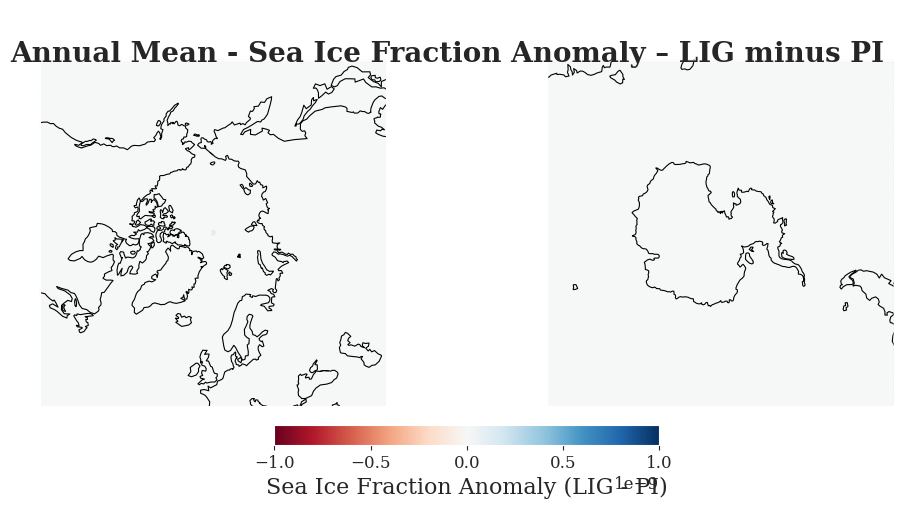

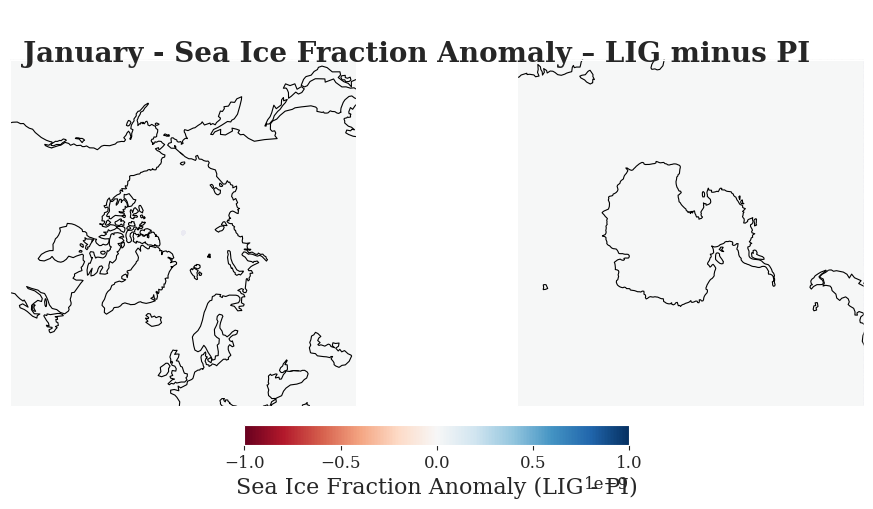

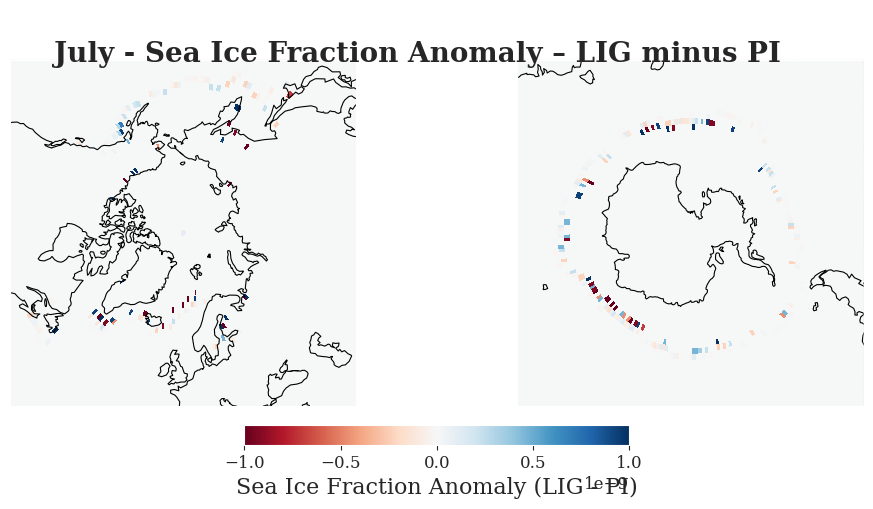

In [61]:
datasets = [
    (Anom_ann_LIG_PI_diff, "Annual Mean"),
    (Anom_Jan_LIG_PI_diff, "January"),
    (Anom_Jul_LIG_PI_diff, "July"),
]

for ds, label in datasets:
    data = ds["fr_seaice"]

    # Compute symmetric colorbar limits per plot
    vmax = np.nanpercentile(np.abs(data.values), 98)
    vmax = 0.000000001
    vmin = -vmax

    fig = plt.figure(figsize=(12, 5))

    # Northern Hemisphere
    ax_n = fig.add_subplot(1, 2, 1, projection=ccrs.NorthPolarStereo())
    im = data.plot(ax=ax_n, transform=ccrs.PlateCarree(), cmap="RdBu",
                   vmin=vmin, vmax=vmax, add_colorbar=False)
    ax_n.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
    ax_n.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())
    #ax_n.set_title("Northern Hemisphere")
    ax_n.set_title("")

    # Southern Hemisphere
    ax_s = fig.add_subplot(1, 2, 2, projection=ccrs.SouthPolarStereo(central_longitude=180))
    data.plot(ax=ax_s, transform=ccrs.PlateCarree(), cmap="RdBu",
              vmin=vmin, vmax=vmax, add_colorbar=False)
    ax_s.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
    ax_s.set_extent([-180, 180, -90, -45], crs=ccrs.PlateCarree())
    #ax_s.set_title("Southern Hemisphere")
    ax_s.set_title("")

    # Shared colorbar
    cbar = fig.colorbar(im, ax=[ax_n, ax_s], orientation="horizontal",
                        fraction=0.05, pad=0.05, shrink=0.6)
    cbar.set_label("Sea Ice Fraction Anomaly (LIG - PI)")

    fig.suptitle(f"\n{label} - Sea Ice Fraction Anomaly – LIG minus PI ",
                 fontsize=20, fontweight="bold")
    plt.savefig(f'figs/sif_{label}_kira_remapped_anom_lig_pi.png')

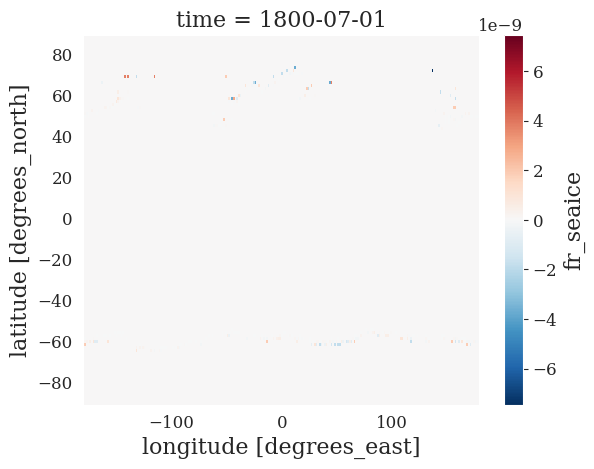

In [47]:
Anom_Jul_LIG_PI_diff['fr_seaice'].plot()

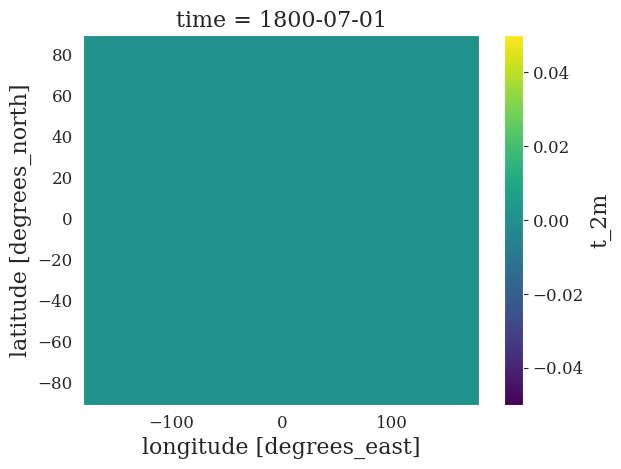

In [48]:
Anom_Jul_LIG_PI_diff['t_2m'].plot()

In [51]:
Anom_Jul_LIG_PI_diff['t_2m']

<xarray.DataArray 't_2m' (time: 1, lat: 120, lon: 240)>
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * time     (time) datetime64[ns] 1800-07-01
  * lon      (lon) float64 -180.0 -178.5 -177.0 -175.5 ... 175.5 177.0 178.5
  * lat      (lat) float64 -90.0 -88.5 -87.0 -85.5 -84.0 ... 84.0 85.5 87.0 88.5

In [16]:
Anom_Jul_LIG_PI_or

<xarray.Dataset>
Dimensions:    (time: 1, lon: 480, lat: 240, height_2: 1, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 1800-07-01
  * lon        (lon) float64 -180.0 -179.2 -178.5 -177.8 ... 177.8 178.5 179.2
  * lat        (lat) float64 -90.0 -89.25 -88.5 -87.75 ... 87.0 87.75 88.5 89.25
  * height_2   (height_2) float64 2.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) timedelta64[ns] 00:00:00 00:00:00
    t_2m       (time, height_2, lat, lon) float32 -0.2 -0.2 -0.2 ... 1.592 1.592
    fr_seaice  (time, lat, lon) float32 0.0 0.0 0.0 ... -0.0003861 -0.0004033

In [27]:
(PI-PI_or).fr_seaice.values.sum()

0.0

In [31]:
(PI-PI_or).t_2m.values.sum()

0.0

In [28]:
PI

<xarray.Dataset>
Dimensions:        (time: 12, bnds: 2, lon: 240, lat: 120)
Coordinates:
  * time           (time) datetime64[ns] 1800-01-01 1800-02-01 ... 1800-12-01
  * lon            (lon) float64 -180.0 -178.5 -177.0 ... 175.5 177.0 178.5
  * lat            (lat) float64 -90.0 -88.5 -87.0 -85.5 ... 84.0 85.5 87.0 88.5
    height         float64 10.0
    height_2       float64 2.0
Dimensions without coordinates: bnds
Data variables: (12/39)
    time_bnds      (time, bnds) datetime64[ns] 1770-01-01 ... 1800-12-01
    pres_msl       (time, lat, lon) float32 9.905e+04 9.905e+04 ... 1.019e+05
    pres_sfc       (time, lat, lon) float32 6.778e+04 6.778e+04 ... 1.019e+05
    t_s            (time, lat, lon) float32 241.0 241.0 241.0 ... 241.4 241.4
    clct           (time, lat, lon) float32 47.71 47.71 47.71 ... 69.71 69.7
    tot_prec_rate  (time, lat, lon) float32 1.137e-06 1.137e-06 ... 4.067e-06
    ...             ...
    t_ice          (time, lat, lon) float32 241.0 241.0 241.0 ... 240.9 240.8
    h_ice          (time, lat, lon) float32 0.0 0.0 0.0 0.0 ... 2.745 2.747 2.75
    albvisdif      (time, lat, lon) float32 89.0 89.0 89.0 ... 74.43 74.44 74.44
    albvisdir      (time, lat, lon) float32 89.0 89.0 89.0 ... 98.38 98.38 98.39
    albnirdif      (time, lat, lon) float32 72.0 72.0 72.0 ... 74.43 74.44 74.44
    albnirdir      (time, lat, lon) float32 72.0 72.0 72.0 ... 98.38 98.38 98.39
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    source:       unknown@retrieved from the configure script
    institution:  Max Planck Institute for Meteorology/Deutscher Wetterdienst
    title:        ICON simulation
    history:      Wed Mar 11 14:39:54 2026: cdo ymonmean PI.kepler_atm2d_merg...
    references:   see MPIM/DWD publications
    comment:      Sebastian Wagner (g261022) on l30076 (Linux 4.18.0-513.24.1...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

In [37]:
PI_or_interp = PI_or.interp(lat=PI.lat, lon=PI.lon)

In [40]:
PI_dif

<xarray.Dataset>
Dimensions:    (time: 12, lon: 240, lat: 120, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 1800-01-01 1800-02-01 ... 1800-12-01
  * lon        (lon) float64 -180.0 -178.5 -177.0 -175.5 ... 175.5 177.0 178.5
  * lat        (lat) float64 -90.0 -88.5 -87.0 -85.5 ... 84.0 85.5 87.0 88.5
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) timedelta64[ns] 00:00:00 00:00:00 ... 00:00:00
    t_2m       (time, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    fr_seaice  (time, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

AttributeError: Rectangle.set() got an unexpected keyword argument 'cmap'

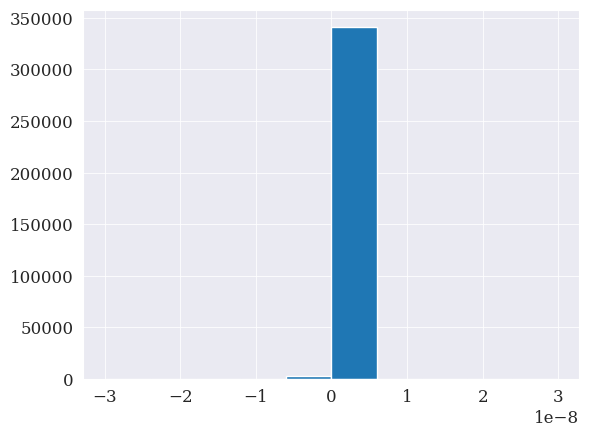

In [42]:
PI_dif = PI - PI_or_interp
#PI_dif.fr_seaice.plot()
PI_dif["fr_seaice"].plot(cmap = 'RdBu')

In [43]:
PI_dif

<xarray.Dataset>
Dimensions:    (time: 12, lon: 240, lat: 120, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 1800-01-01 1800-02-01 ... 1800-12-01
  * lon        (lon) float64 -180.0 -178.5 -177.0 -175.5 ... 175.5 177.0 178.5
  * lat        (lat) float64 -90.0 -88.5 -87.0 -85.5 ... 84.0 85.5 87.0 88.5
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) timedelta64[ns] 00:00:00 00:00:00 ... 00:00:00
    t_2m       (time, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    fr_seaice  (time, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

Text(0.5, 1.0, 'Sea Ice Fraction - Anomaly - LIG-PI - R2B4 - R0B4 July')

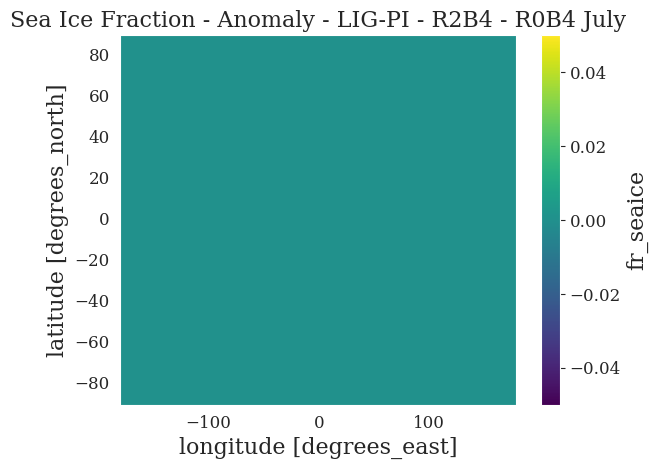

In [9]:
Anom_Jul_LIG_PI_diff["fr_seaice"].plot()
plt.title("Sea Ice Fraction - Anomaly - LIG-PI - R2B4 - R0B4 July")

In [6]:
LIG_Jul["fr_seaice"]

<xarray.DataArray 'fr_seaice' (time: 1, lat: 240, lon: 480)>
[115200 values with dtype=float32]
Coordinates:
  * time      (time) datetime64[ns] 1800-07-01
  * lon       (lon) float64 -180.0 -179.2 -178.5 -177.8 ... 177.8 178.5 179.2
  * lat       (lat) float64 -90.0 -89.25 -88.5 -87.75 ... 87.0 87.75 88.5 89.25
    height_2  float64 2.0
Attributes:
    standard_name:  fr_seaice
    long_name:      fraction of sea ice
    units:          1
    param:          0.2.10

## Basic SIF Plot LIG

Text(0.5, 1.0, 'Sea Ice Fraction - LIG July')

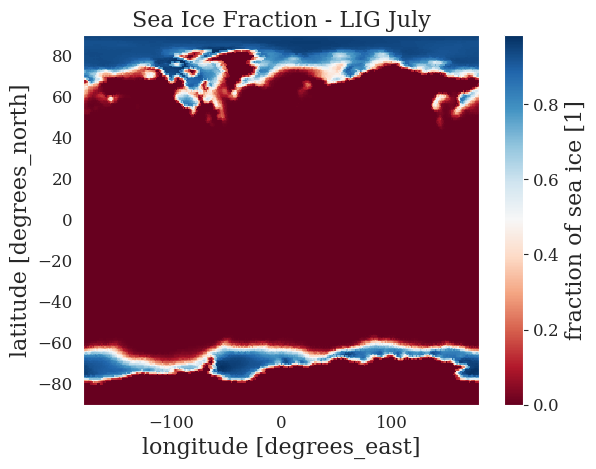

In [7]:
LIG_Jul["fr_seaice"].plot(cmap = 'RdBu')
plt.title("Sea Ice Fraction - LIG July")

## Basic SIF Plot PI

Text(0.5, 1.0, 'Sea Ice Fraction - PI July')

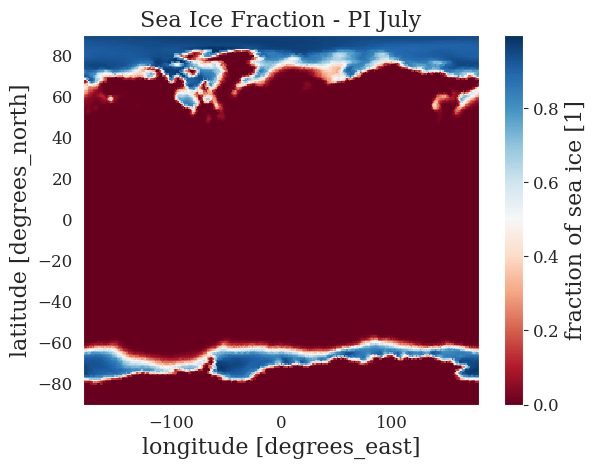

In [8]:
PI_Jul["fr_seaice"].plot(cmap = 'RdBu')
plt.title("Sea Ice Fraction - PI July")

## Plotting SIF Anomaly

Text(0.5, 1.0, 'Sea Ice Fraction - Anomaly - LIG-PI July')

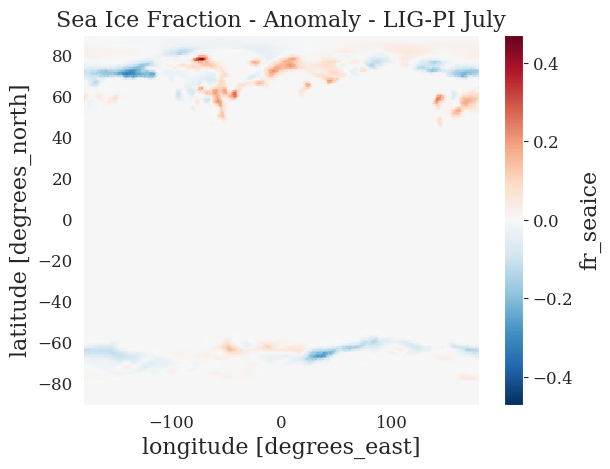

In [9]:
Anom_Jul_LIG_PI["fr_seaice"].plot()
plt.title("Sea Ice Fraction - Anomaly - LIG-PI July")

## Adding Coastlines

Text(0.5, 1.0, 'Sea Ice Fraction - Anomaly - LIG-PI July')

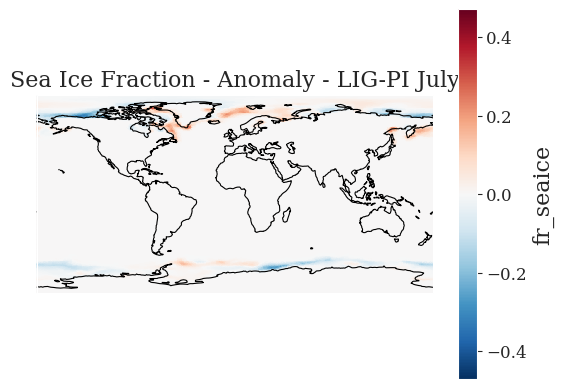

In [10]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
Anom_Jul_LIG_PI["fr_seaice"].plot(ax=ax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
plt.title("Sea Ice Fraction - Anomaly - LIG-PI July")

## Inverting Colormap

Text(0.5, 1.0, 'Sea Ice Fraction - Anomaly - LIG-PI July')

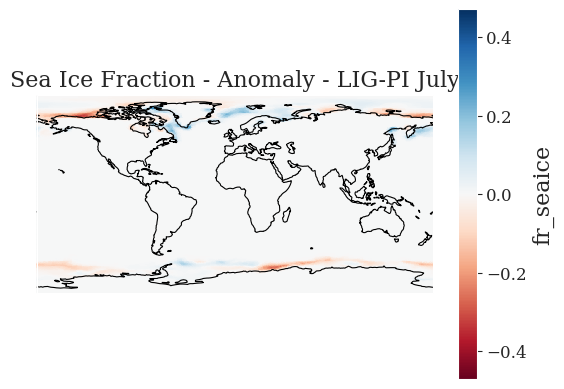

In [11]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
Anom_Jul_LIG_PI["fr_seaice"].plot(ax=ax, transform=ccrs.PlateCarree(), cmap = 'RdBu')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
plt.title("Sea Ice Fraction - Anomaly - LIG-PI July")

## Switching to North Pole South Pole Scale

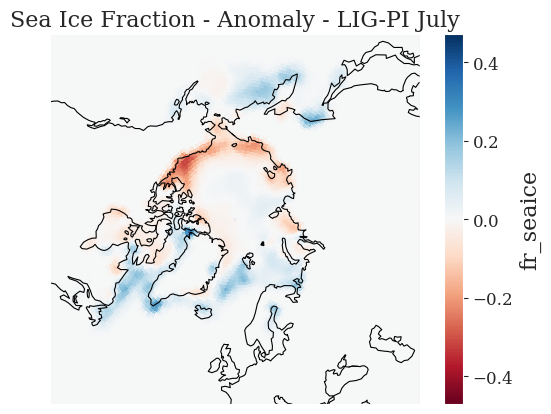

In [12]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.NorthPolarStereo()})
Anom_Jul_LIG_PI["fr_seaice"].plot(ax=ax, transform=ccrs.PlateCarree(), cmap = 'RdBu')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
plt.title("Sea Ice Fraction - Anomaly - LIG-PI July")
ax.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())

## Full Plot in one Image

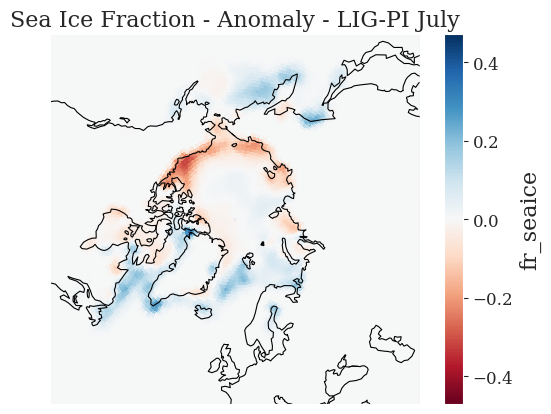

In [13]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.NorthPolarStereo()})
Anom_Jul_LIG_PI["fr_seaice"].plot(ax=ax, transform=ccrs.PlateCarree(), cmap = 'RdBu')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
plt.title("Sea Ice Fraction - Anomaly - LIG-PI July")
ax.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())

## Big Sea Ice Anomaly Plot

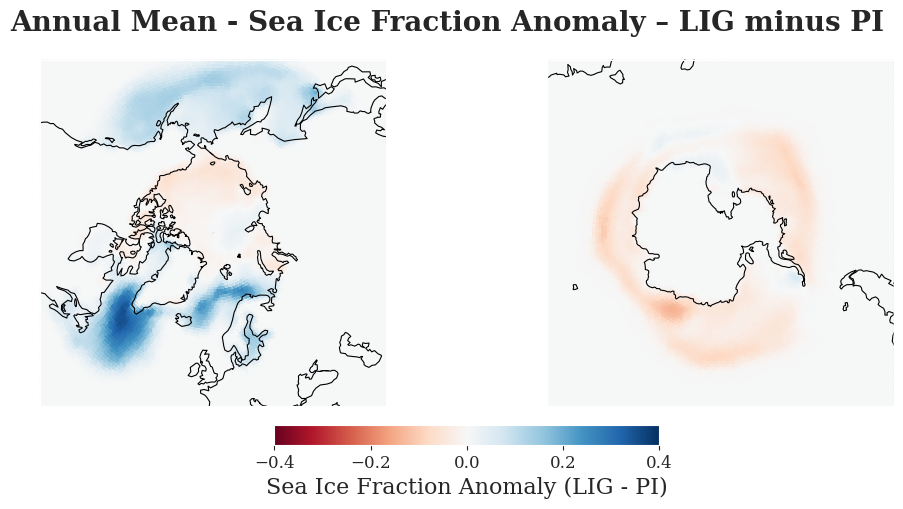

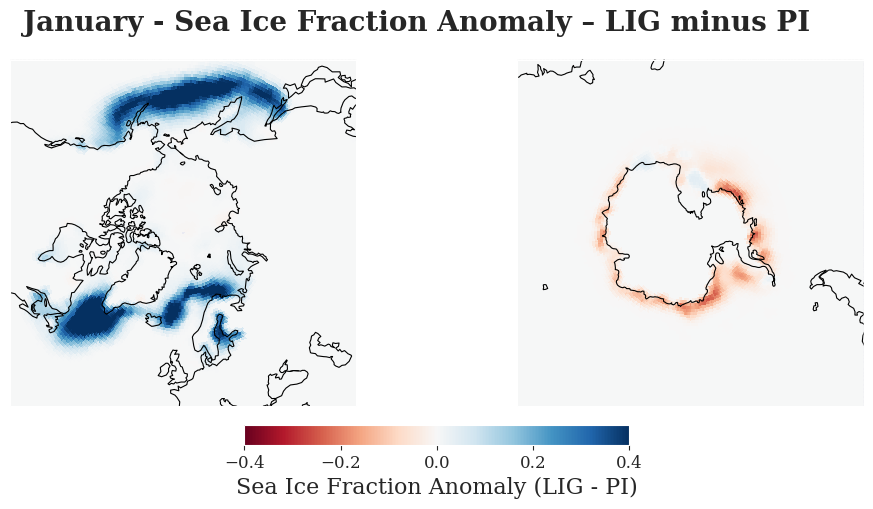

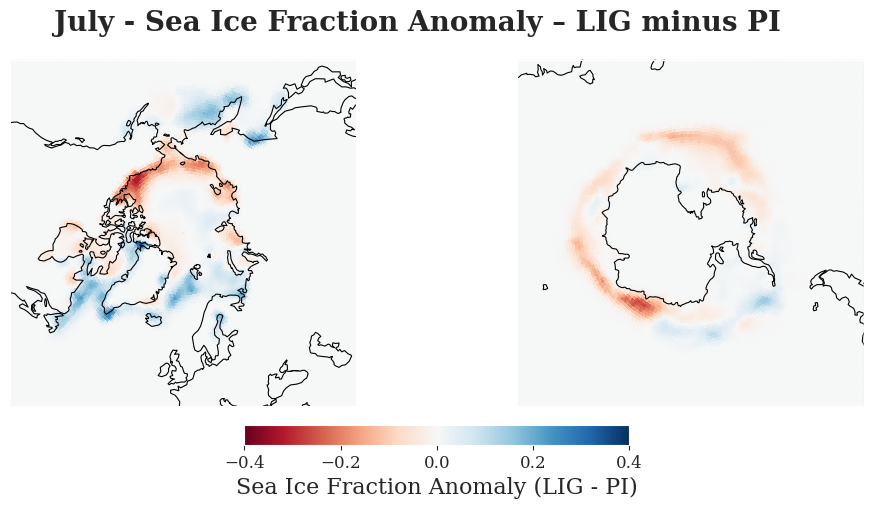

In [22]:
datasets = [
    (Anom_ann_LIG_PI, "Annual Mean"),
    (Anom_Jan_LIG_PI, "January"),
    (Anom_Jul_LIG_PI, "July"),
]

for ds, label in datasets:
    data = ds["fr_seaice"]

    # Compute symmetric colorbar limits per plot
    #vmax = np.nanpercentile(np.abs(data.values), 98)
    vmax = 0.4
    vmin = -vmax

    fig = plt.figure(figsize=(12, 5))

    # Northern Hemisphere
    ax_n = fig.add_subplot(1, 2, 1, projection=ccrs.NorthPolarStereo())
    im = data.plot(ax=ax_n, transform=ccrs.PlateCarree(), cmap="RdBu",
                   vmin=vmin, vmax=vmax, add_colorbar=False)
    ax_n.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
    ax_n.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())
    #ax_n.set_title("Northern Hemisphere")
    ax_n.set_title("")

    # Southern Hemisphere
    ax_s = fig.add_subplot(1, 2, 2, projection=ccrs.SouthPolarStereo(central_longitude=180))
    data.plot(ax=ax_s, transform=ccrs.PlateCarree(), cmap="RdBu",
              vmin=vmin, vmax=vmax, add_colorbar=False)
    ax_s.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
    ax_s.set_extent([-180, 180, -90, -45], crs=ccrs.PlateCarree())
    #ax_s.set_title("Southern Hemisphere")
    ax_s.set_title("")

    # Shared colorbar
    cbar = fig.colorbar(im, ax=[ax_n, ax_s], orientation="horizontal",
                        fraction=0.05, pad=0.05, shrink=0.6)
    cbar.set_label("Sea Ice Fraction Anomaly (LIG - PI)")

    fig.suptitle(f"{label} - Sea Ice Fraction Anomaly – LIG minus PI ",
                 fontsize=20, fontweight="bold")
    plt.savefig(f'figs/sif_{label}_kira_remapped_anom_lig_pi.png')
    

## Same Sea Ice Anomaly Plot but different Colorbarlimits

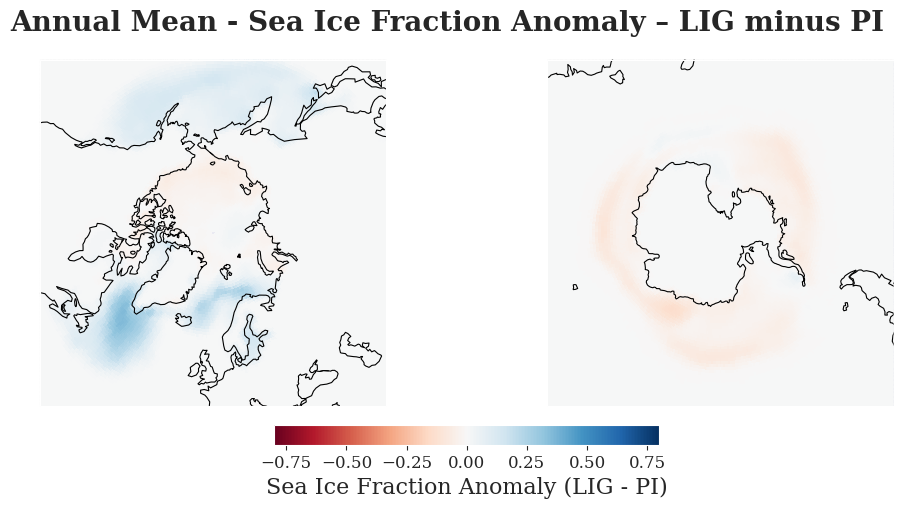

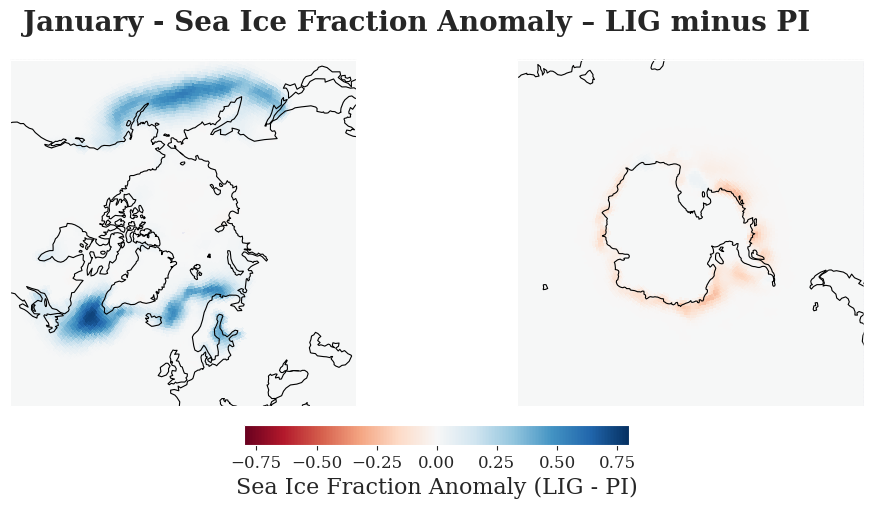

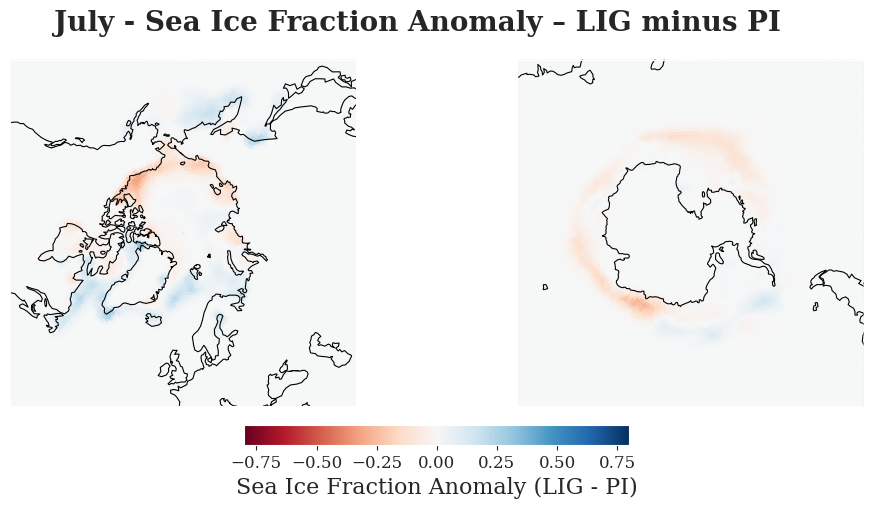

In [21]:
datasets = [
    (Anom_ann_LIG_PI, "Annual Mean"),
    (Anom_Jan_LIG_PI, "January"),
    (Anom_Jul_LIG_PI, "July"),
]

for ds, label in datasets:
    data = ds["fr_seaice"]

    # Compute symmetric colorbar limits per plot
    #vmax = np.nanpercentile(np.abs(data.values), 98)
    vmax = 0.8
    vmin = -vmax

    fig = plt.figure(figsize=(12, 5))

    # Northern Hemisphere
    ax_n = fig.add_subplot(1, 2, 1, projection=ccrs.NorthPolarStereo())
    im = data.plot(ax=ax_n, transform=ccrs.PlateCarree(), cmap="RdBu",
                   vmin=vmin, vmax=vmax, add_colorbar=False)
    ax_n.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
    ax_n.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())
    #ax_n.set_title("Northern Hemisphere")
    ax_n.set_title("")

    # Southern Hemisphere
    ax_s = fig.add_subplot(1, 2, 2, projection=ccrs.SouthPolarStereo(central_longitude=180))
    data.plot(ax=ax_s, transform=ccrs.PlateCarree(), cmap="RdBu",
              vmin=vmin, vmax=vmax, add_colorbar=False)
    ax_s.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
    ax_s.set_extent([-180, 180, -90, -45], crs=ccrs.PlateCarree())
    #ax_s.set_title("Southern Hemisphere")
    ax_s.set_title("")

    # Shared colorbar
    cbar = fig.colorbar(im, ax=[ax_n, ax_s], orientation="horizontal",
                        fraction=0.05, pad=0.05, shrink=0.6)
    cbar.set_label("Sea Ice Fraction Anomaly (LIG - PI)")

    fig.suptitle(f"{label} - Sea Ice Fraction Anomaly – LIG minus PI ",
                 fontsize=20, fontweight="bold")
    plt.savefig(f'figs/sif_{label}_kira_remapped_anom_lig_pi_0_8_colorbar_limits.png')
    

# Proof Kiras Plot is "Wrong"

Text(0.5, 1.0, 'Sea Ice Fraction - PI - July')

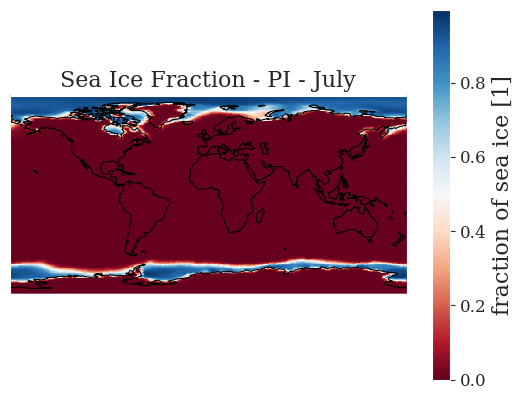

In [15]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
PI_Jul["fr_seaice"].plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
plt.title("Sea Ice Fraction - PI - July")

Text(0.5, 1.0, 'Sea Ice Fraction - LIG - July')

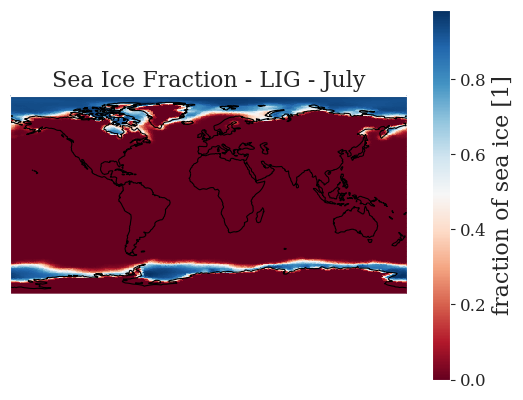

In [16]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
LIG_Jul["fr_seaice"].plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
plt.title("Sea Ice Fraction - LIG - July")

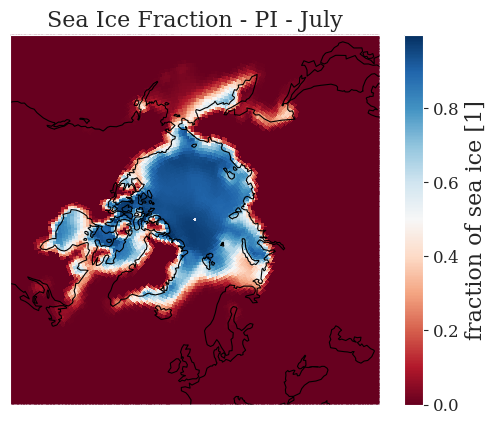

In [17]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.NorthPolarStereo()})
PI_Jul["fr_seaice"].plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
plt.title("Sea Ice Fraction - PI - July")
ax.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())

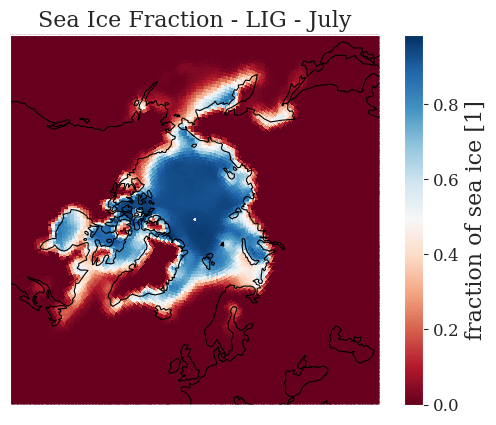

In [18]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.NorthPolarStereo()})
LIG_Jul["fr_seaice"].plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")
plt.title("Sea Ice Fraction - LIG - July")
ax.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())

### In the above plot at the area south of greenland the LIG sea ice is 0.5 at Maximum (probably reather 0.3-0.4). So the Anomaly LIG-PI cannot be higher! But in Kiras Plot there we have an anomaly of 0.8
I think Kiras Data Plots use  some different data! Also the position of the maxima and minima is sometimes quite different.